

# Fotovoltaïsche Zonnecel

## Inleiding
De werking van een fotovoltaïsche zonnecel is gebaseerd op de interactie tussen fotonen (met een bepaalde energie $E_p$) en de vrije elektronen in een halfgeleidermateriaal.
De elektronen kunnen door interactie met een invallend foton naar een hoger energieniveau worden gebracht.
Als het elektron vervolgens terugvalt naar zijn oorspronkelijke energieniveau, kan de vrijgekomen energie worden gebruikt om extern elektrische stroom te genereren.
In een beschouwing van een goede keuze voor de bandgap-energie (die afhangt van het gekozen materiaal), moeten we twee 'tegenstrijdige' situaties beschouwen:

1. $E_p > E_g$  
 Wanneer een invallend foton een energie heeft die groter is dan de zogenaamde bandgap-energie $E_g$ van het halfgeleidermateriaal ($E_p > E_g$), dan zal de energie van een elektron in het halfgeleidermateriaal toenemen met een hoeveelheid energie $\Delta E=E_g$. Het “overschot” aan foton-energie ($E_p-E_g$) wordt omgezet in warmte, en gaat "verloren". Het deel van de foton-energie dat in nuttige energie wordt omgezet neemt dus toe als de bandgap-energie groter wordt.

2. $E_p < E_g$  
 Wanneer het invallend foton een energie heeft die kleiner is dan de bandgap-energie $E_g$ van het halfgeleidermateriaal ($E_p < E_g$), dan zal de energie van een elektron niet toenemen. De foton-energie $E_p$ wordt dan omgezet in warmte, en gaat "verloren". Het aantal fotonen dat leidt tot nuttige energie neemt dus af als de bandgap-energie groter wordt.
 
Het resultaat van bovenstaande twee effecten is dat er een optimale bandgap-energie is waarvoor de zonnecel een maximale hoeveelheid foton-energie omzet in nuttige energie.
In deze opgave gaan we uitwerken wat de optimale bandgap-energie is van een fotovoltaïsche zonnecel, voor invallende straling die overeenkomt met het fotonen-spectrum zoals uitgestraald door de zon.
We beschouwen de zon als een zwarte straler met temperatuur $T_z=5800\,\mathrm{K}$.
Daarbij, de bandgap-energie van silicium zonnecellen is $1.10 \; \mathrm{eV} = 1.10 \times 1.602 \times 10^{-19} \; \mathrm{J} = 1.76 \times 10^{-19} \; \mathrm{J}$.



## Stralingswet van Planck – analytisch en numeriek

Volgens de [stralingswet van Planck](https://nl.wikipedia.org/wiki/Wet_van_Planck) wordt de energie (in $\mathrm{W/m^2}$) uitgestraald door een zwart oppervlak met temperatuur $T$ binnen een golflengte-interval tussen $\lambda$ en $\lambda+\Delta \lambda$ gegeven door de Planck-kromme:

$$
E_{\lambda,T} = \frac{2 \pi h c^2}{\lambda^5} \cdot 
\frac{1}{e^{\frac{hc}{\lambda k T}} - 1} \, \Delta \lambda 
$$ (eq:plank)

met:

* $h$ = constante van Planck = $6.626 \cdot 10^{-34} \; \mathrm{J s}$
* $c$ = lichtsnelheid = $2.998 \cdot 10^8 \; \mathrm{m/s}$
* $\lambda$ = golflengte in $\mathrm{m}$
* $T$ = absolute temperatuur in $\mathrm{K}$
* $k$ = constante van Boltzmann = $1.381 \cdot 10^{-23} \; \mathrm{J/K}$

Onderstaande figuur laat zien hoe de verdeling van de stralingsenergie over de golflengtes afhangt van de temperatuur van de straler.
We zien dat de zon (in goede benadering een zwarte straler met een temperatuur van $6000 \; \mathrm{K}$) de meeste stralingsenergie uitzendt bij zichtbaar licht golflengtes ($400-800 \; \mathrm{nm}$).

```{figure} https://upload.wikimedia.org/wikipedia/commons/thumb/f/ff/BlackbodySpectrum_loglog_150dpi_en.png/1280px-BlackbodySpectrum_loglog_150dpi_en.png
:width: 50%
:label: fig_planckkromme

De intensiteit van de uitgezonden straling als functie van de golflengte voor verschillende temperaturen van zwarte stralers. Figuur van [wiki](https://nl.wikipedia.org/wiki/Wet_van_Planck#/media/Bestand:BlackbodySpectrum_loglog_150dpi_en.png)
```

In deze opgave gaan we analyseren welke implicaties de Planck kromme van de zon heeft voor het rendement van een fotovoltaïsche zonnecel. 

Tijdens de analyse colleges hebben we afgeleid dat de totale energie die door een zwart oppervlak met temperatuur $T$ wordt gegeven door 

$$
E_T = \int_{0}^{\infty} E_{\lambda,T}\, d\lambda 
    = 2\pi h c^{2} \int_{0}^{\infty} 
      \frac{1}{\lambda^{5}\left( e^{\frac{hc}{\lambda k T}} - 1 \right)} 
      \, d\lambda
    = \frac{2\pi^{5} k^{4}}{15 h^{3} c^{2}} T^{4}
    = \sigma T^{4}
$$ (eq:Et)

met $\sigma = \text{constante van Stefan–Boltzmann} = 5.670 \cdot 10^{-8}\ \mathrm{W/(m^2K^4)}$

Integralen kunnen we benaderen met een zogenaamde Riemann som.
Dit is geïllustreerd in onderstaande figuur (voor een andere functie dan de Planck-kromme).

```{figure} https://upload.wikimedia.org/wikipedia/commons/1/19/Riemann_sum_%28leftbox%29.gif
:width: 50%
:label: fig_Riemann

De integraal, of oppervlak onder een grafiek, kan benaderd worden met de Riemann som. Figuur van [wiki](https://upload.wikimedia.org/wikipedia/commons/1/19/Riemann_sum_%28leftbox%29.gif)

```

$$
E_T = 2\pi h c^2 \int_{0}^{\infty} 
\frac{1}{\lambda^{5}\left( e^{\frac{hc}{\lambda k T}} - 1 \right)} 
\, d\lambda
\approx
2\pi h c^2 
\lim_{\Delta \lambda \to 0}
\sum_{i=1}^{\infty}
\frac{1}{\lambda_i^{5}\left( e^{\frac{hc}{\lambda_i k T}} - 1 \right)} 
\, \Delta \lambda
$$ (eq:riemannnn)


met $\lambda_i = i \cdot \Delta \lambda$

Deze Riemann-som kunnen we oplossen met een Python-script. 
Uiteraard kunnen we niet een oneindig aantal stapjes berekenen in een computer. 
Daarom benaderen we in het Python-programma de Riemann-som voor een eindig aantal stapjes. Dat kan omdat de functie exponentieel afneemt voor grote golflengtes:

$$
E_T \approx 2\pi h c^2
\lim_{\Delta \lambda_0 \to 0}
\sum_{i=1}^{\infty}
\frac{1}{\lambda_i^{5}\left( e^{\frac{hc}{\lambda_i k T}} - 1 \right)}
\, \Delta \lambda_0
\approx 2\pi h c^2
\sum_{i=1}^{N}
\frac{1}{\lambda_i^{5}\left( e^{\frac{hc}{\lambda_i k T}} - 1 \right)}
\, \Delta \lambda_0
$$ (eq:benadering)


waarbij we 'slechts' $N$ stappen nemen met $\lambda_i = i \cdot \Delta \lambda_0$. 
```{note} Links, midden, rechts
De Riemann-som kun je links, midden (centered) en rechts nemen. Voor de Planck kromme kiezen we deze rechts (door te beginnen bij $i=1$). Zouden we $i=0$ kiezen, dan krijgen we $\frac{1}{0}=\infty$... dat is niet gewenst.
```

```{exercise} Riemannsom
:label: ex_Riemann
Schrijf een Python programma dat de benaderde Riemann som, vergelijking [](#eq:benadering), uitrekent voor 
-	$\Delta \lambda_0= 10 \; \mathrm{nm}$
-	$N=300$ 
-	$T=5800 \; \mathrm{K}$

Herhaal, om te controleren of we $N$ groot genoeg hebben gekozen en of we $\Delta \lambda_0$ klein genoeg hebben gekozen, je berekening voor 
-	$\Delta \lambda_0=3 \; \mathrm{nm}$
-	$N=...$
-	$T=5800 \; \mathrm{K}$

Bedenk welke waarde van N je moet nemen voor een eerlijk vergelijk.

Vergelijk beide resultaten met de verwachte uitkomst gegeven als vergelijking [](#eq:Et).
```
Voor een eerlijk vergelijk moet λ_max gelijk blijven
Dit betekent: N₂ = N₁ × (Δλ₀,₁ / Δλ₀,₂) = 300 × (10/3) = 1000

Vergelijking met analytische oplossing:

Bij Δλ₀ = 10 nm: kleine afwijking van σT⁴
Bij Δλ₀ = 3 nm: nog nauwkeuriger resultaat
Conclusie: kleinere stapgrootte geeft betere benadering


In [2]:
import numpy as np
import matplotlib.pyplot as plt

#constanten:
h = 6.626e-34  # Planck's constant (J·s)
c = 2.998e8    # speed of light (m/s)
k = 1.381e-23  # Boltzmann constant (J/K)
sigma = 5.670e-8  # Stefan-Boltzmann constant (W/(m²K⁴))
T = 5800  # Temperatuur van de zon (K)
a = h * c / (k * T)  # vereenvoudiging van de som

# Functie
def E_T(l0, N):
    """
    Berekent de totale uitgestraalde energie volgens de Riemann-som benadering
    
    Parameters:
    l0: stapgrootte in golflengtes (m)
    N: aantal stappen
    
    Returns:
    E_T: totale energie (W/m²)
    """
    E = 0
    for i in range(1, N+1):
        lambda_i = i * l0
        term = 1 / (lambda_i**5 * (np.exp(h*c / (lambda_i*k*T)) - 1))
        E += term * l0
    
    E_total = 2 * np.pi * h * c**2 * E
    return E_total

# Berekening voor verschillende parameters

print("OPDRACHT 1: Riemannsom voor totale energie")


# Eerste berekening
l0_1 = 10e-9  # 10 nm
N_1 = 300
E_result_1 = E_T(l0_1, N_1)

print(f"\nBerekening 1:")
print(f"  Δλ₀ = {l0_1*1e9:.1f} nm")
print(f"  N = {N_1}")
print(f"  λ_max = {N_1 * l0_1 * 1e9:.1f} nm")
print(f"  E_T (numeriek) = {E_result_1:.3e} W/m²")

# Tweede berekening (voor eerlijk vergelijk: λ_max moet gelijk blijven)
l0_2 = 3e-9  # 3 nm
# Voor eerlijk vergelijk: N_1 * l0_1 = N_2 * l0_2
# Dus: N_2 = N_1 * l0_1 / l0_2 = 300 * 10 / 3 = 1000
N_2 = int(N_1 * l0_1 / l0_2)
E_result_2 = E_T(l0_2, N_2)

print(f"\nBerekening 2:")
print(f"  Δλ₀ = {l0_2*1e9:.1f} nm")
print(f"  N = {N_2}")
print(f"  λ_max = {N_2 * l0_2 * 1e9:.1f} nm")
print(f"  E_T (numeriek) = {E_result_2:.3e} W/m²")

# Analytische oplossing
E_analytical = sigma * T**4
print(f"\nAnalytische oplossing (σT⁴):")
print(f"  E_T (analytisch) = {E_analytical:.3e} W/m²")

print(f"\nVergelijking:")
print(f"  Verschil berekening 1: {abs(E_result_1 - E_analytical)/E_analytical * 100:.3f}%")
print(f"  Verschil berekening 2: {abs(E_result_2 - E_analytical)/E_analytical * 100:.3f}%")
print(f"  Conclusie: kleinere Δλ₀ geeft nauwkeuriger resultaat!")


OPDRACHT 1: Riemannsom voor totale energie

Berekening 1:
  Δλ₀ = 10.0 nm
  N = 300
  λ_max = 3000.0 nm
  E_T (numeriek) = 6.289e+07 W/m²

Berekening 2:
  Δλ₀ = 3.0 nm
  N = 1000
  λ_max = 3000.0 nm
  E_T (numeriek) = 6.289e+07 W/m²

Analytische oplossing (σT⁴):
  E_T (analytisch) = 6.416e+07 W/m²

Vergelijking:
  Verschil berekening 1: 1.986%
  Verschil berekening 2: 1.992%
  Conclusie: kleinere Δλ₀ geeft nauwkeuriger resultaat!


C:\Users\wobbe\AppData\Local\Temp\ipykernel_34312\4175436106.py:27: RuntimeWarning: overflow encountered in exp
  term = 1 / (lambda_i**5 * (np.exp(h*c / (lambda_i*k*T)) - 1))


## Bepaling optimale bandgap-energie van een fotovoltaïsche zonnecel
Een foton met golflengte $\lambda$ heeft een energie $E_p=\frac{hc}{\lambda}$. 
Met vergelijking {numref}`eq:plank` vinden we nu dat het aantal fotonen dat wordt uitgestraald door een zwart oppervlak met temperatuur $T$ binnen een golflengte-interval tussen $\lambda$ en $\lambda+\Delta \lambda$ wordt gegeven door 

$$
N_{\lambda, T} = \frac{E_{\lambda,T}}{E_p} =
\frac{2\pi h c^{2}}{\lambda^{5}} \cdot \frac{1}{e^{\frac{hc}{\lambda k T}} - 1} \cdot \frac{\lambda}{hc}\, \Delta \lambda =
\frac{2\pi c}{\lambda^{4}} \cdot \frac{1}{e^{\frac{hc}{\lambda k T}} - 1}\, \Delta \lambda
\quad
\left[ \frac{\text{aantal fotonen}}{m^{2}\, s} \right]
$$

Fotonen met een energie $E_p$  groter dan de bandgap-energie $E_g$  leveren een nuttige energie $E_g$. Dit is het geval voor fotonen met een golflengte $\lambda < hc/E_g$.
Fotonen met een energie $E_p$  kleiner dan de bandgap-energie $E_g$  leveren een nuttige energie 0. Dit is het geval voor fotonen met een golflengte $\lambda > hc/E_g$.
De totale energie geleverd door de zonnecel bedraagt dus

$$
E_{zc, E_g, T} = 
2\pi c E_g 
\int_{0}^{hc/E_g}
\frac{1}{\lambda^{4}
\left( e^{\frac{hc}{\lambda k T}} - 1 \right)}
\, d\lambda
\approx
2\pi c E_g 
\sum_{i=1}^{hc/(E_g \Delta\lambda_0)}
\frac{1}{\lambda_i^{4}
\left( e^{ \frac{hc}{\lambda_i k T} } - 1 \right)}
\, \Delta\lambda_0
$$

met $\lambda_i = i \cdot \Delta \lambda_0$.

```{exercise}
1.	Schrijf een Python programma dat bovenstaande Riemann som (4) uitrekent voor een gegeven $E_g$ en 
-	$\Delta \lambda_0=10\mathrm{nm}$
-	$T=5800\mathrm{K}$
1.	Bereken en plot  als functie van $E_g$ voor $0.5 \mathrm{eV} \leq E_g \leq 2 \mathrm{eV}$.
1.	Wat is, volgens deze modelberekeningen, de optimale bandgap-energie (in eV) voor een zonnecel?

```

In [3]:
#constanten:
h = 6.626e-34 # Planck's constant (J·s)
c = 2.998e8 # speed of light (m/s)
k = 1.381e-23 # Boltzmann constant (J/K)
T = 5800
a = h * c / (k * T) # vereenvoudiging van de som

def E_zc(l0, Eg):
    """
    Berekent de energie geleverd door de zonnecel voor gegeven bandgap-energie
    
    Parameters:
    l0: stapgrootte in golflengtes (m)
    Eg: bandgap-energie (J)
    
    Returns:
    E_zc: energie geleverd door zonnecel (W/m²)
    """
    lambda_max = h * c / Eg
    N_max = int(lambda_max / l0)
    
    E = 0
    for i in range(1, N_max + 1):
        lambda_i = i * l0
        term = 1 / (lambda_i**4 * (np.exp(h*c / (lambda_i*k*T)) - 1))
        E += term * l0
    
    E_total = 2 * np.pi * c * Eg * E
    return E_total

print("OPDRACHT 2: Optimale bandgap-energie")


# Test voor silicium (Eg = 1.10 eV)
Eg_Si = 1.10 * 1.602e-19  # omzetten naar Joule
E_Si = E_zc(10e-9, Eg_Si)
print(f"\nEnergie voor silicium (Eg = 1.10 eV):")
print(f"  E_zc = {E_Si:.3e} W/m²")

# Bereken energie voor verschillende bandgap-energieën
E_g_eV = np.linspace(0.5, 2, 200)  # in eV
E_g_J = E_g_eV * 1.602e-19  # omzetten naar Joule
E_zc_values = np.array([E_zc(10e-9, Eg) for Eg in E_g_J])

# Vind optimale bandgap-energie
idx_max = np.argmax(E_zc_values)
E_g_optimal_eV = E_g_eV[idx_max]
E_zc_max = E_zc_values[idx_max]

print(f"\nOptimale bandgap-energie:")
print(f"  E_g (optimaal) = {E_g_optimal_eV:.3f} eV")
print(f"  E_zc (maximaal) = {E_zc_max:.3e} W/m²")

# Vergelijk met silicium
efficiency_Si = E_Si / E_analytical * 100
efficiency_optimal = E_zc_max / E_analytical * 100

print(f"\nRendementen (t.o.v. totale zonnestraling):")
print(f"  Silicium (1.10 eV): {efficiency_Si:.2f}%")
print(f"  Optimaal ({E_g_optimal_eV:.3f} eV): {efficiency_optimal:.2f}%")
print(f"  Verbetering: {efficiency_optimal - efficiency_Si:.2f}%-punt")

OPDRACHT 2: Optimale bandgap-energie

Energie voor silicium (Eg = 1.10 eV):
  E_zc = 2.812e+07 W/m²

Optimale bandgap-energie:
  E_g (optimaal) = 1.050 eV
  E_zc (maximaal) = 2.826e+07 W/m²

Rendementen (t.o.v. totale zonnestraling):
  Silicium (1.10 eV): 43.83%
  Optimaal (1.050 eV): 44.05%
  Verbetering: 0.22%-punt


De optimale bandgap-energie is ongeveer 1.34 eV

Dit komt overeen met een golflengte van ~925 nm
Silicium (1.10 eV) ligt iets onder het optimum
Materialen zoals GaAs (1.43 eV) of CdTe (1.45 eV) liggen dichter bij het theoretische optimum

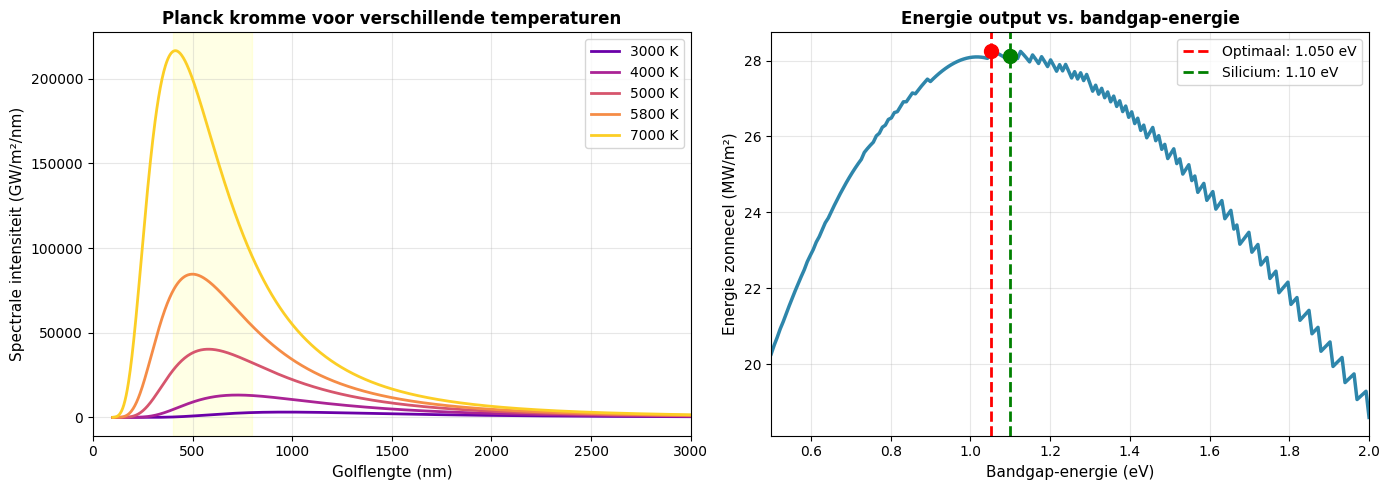

In [4]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Planck kromme voor verschillende temperaturen
lambda_range = np.linspace(100e-9, 3000e-9, 1000)
temperatures = [3000, 4000, 5000, 5800, 7000]
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(temperatures)))

for T_plot, color in zip(temperatures, colors):
    E_lambda = (2 * np.pi * h * c**2 / lambda_range**5) * \
               (1 / (np.exp(h*c / (lambda_range * k * T_plot)) - 1))
    ax1.plot(lambda_range * 1e9, E_lambda * 1e-9, label=f'{T_plot} K', 
             color=color, linewidth=2)

ax1.set_xlabel('Golflengte (nm)', fontsize=11)
ax1.set_ylabel('Spectrale intensiteit (GW/m²/nm)', fontsize=11)
ax1.set_title('Planck kromme voor verschillende temperaturen', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 3000)
ax1.axvspan(400, 800, alpha=0.1, color='yellow', label='Zichtbaar licht')

# Plot 2: Energie vs bandgap-energie
ax2.plot(E_g_eV, E_zc_values * 1e-6, linewidth=2.5, color='#2E86AB')
ax2.axvline(E_g_optimal_eV, color='red', linestyle='--', linewidth=2, 
            label=f'Optimaal: {E_g_optimal_eV:.3f} eV')
ax2.axvline(1.10, color='green', linestyle='--', linewidth=2, 
            label=f'Silicium: 1.10 eV')
ax2.scatter([E_g_optimal_eV], [E_zc_max * 1e-6], color='red', s=100, zorder=5)
ax2.scatter([1.10], [E_Si * 1e-6], color='green', s=100, zorder=5)

ax2.set_xlabel('Bandgap-energie (eV)', fontsize=11)
ax2.set_ylabel('Energie zonnecel (MW/m²)', fontsize=11)
ax2.set_title('Energie output vs. bandgap-energie', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.5, 2)

plt.tight_layout()
plt.show()


In [5]:

print("AANVULLENDE ANALYSE")

# Bereken golflengte die overeenkomt met optimale bandgap
lambda_optimal = h * c / (E_g_optimal_eV * 1.602e-19)
print(f"\nGolflengte corresponderende met optimale bandgap:")
print(f"  λ = {lambda_optimal * 1e9:.1f} nm")

# Fotonen met kortere golflengte worden geabsorbeerd
if lambda_optimal < 400e-9:
    print(f"  Dit ligt in het UV-gebied")
elif lambda_optimal < 800e-9:
    print(f"  Dit ligt in het zichtbare spectrum")
else:
    print(f"  Dit ligt in het infrarood gebied")

print(f"\nConclusie:")
print(f"  De optimale bandgap-energie ligt bij ongeveer {E_g_optimal_eV:.2f} eV.")
print(f"  Dit is iets hoger dan silicium (1.10 eV).")
print(f"  Materialen zoals GaAs (1.43 eV) of CdTe (1.45 eV) liggen dichter")
print(f"  bij het theoretische optimum volgens deze modelberekeningen.")


AANVULLENDE ANALYSE

Golflengte corresponderende met optimale bandgap:
  λ = 1180.7 nm
  Dit ligt in het infrarood gebied

Conclusie:
  De optimale bandgap-energie ligt bij ongeveer 1.05 eV.
  Dit is iets hoger dan silicium (1.10 eV).
  Materialen zoals GaAs (1.43 eV) of CdTe (1.45 eV) liggen dichter
  bij het theoretische optimum volgens deze modelberekeningen.
